Loading data

In [1]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from itertools import product
import seaborn as sns
from collections import Counter


def load_ticker(ticker, start, end):
    return yf.download(
        ticker, 
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

In [46]:
date1 = '2004-11-18'
date2 = '2007-11-30'

gld = load_ticker("GLD", date1, date2)
gdx = load_ticker("GDX", date1, date2)

df = pd.merge(gld, gdx, on = 'Date')
trainset = np.arange(0, 252)
testset = np.arange(trainset.shape[0], df.shape[0])

intersection = gld.index.intersection(gdx.index)
gld = gld.loc[intersection]
gdx = gdx.loc[intersection]


gld_open = gld["Open"].squeeze().dropna()
gld_close = gld["Close"].squeeze().dropna()
gdx_open = gdx["Open"].squeeze().dropna()
gdx_close = gdx["Close"].squeeze().dropna()



In [26]:

split_point_idx = 252
split_point = gld_open.index[split_point_idx]



Finding the hedge ratio 

In [59]:
result = sm.OLS(df['Close']['GLD'].iloc[trainset], df['Close']['GDX'].iloc[trainset]).fit()

hedge_ratio = result.params.iloc[0]

print(hedge_ratio)

1.9167417962512059


z_score function

In [5]:
def spread_fun(stock1, stock2, hedge):
    spread =  stock1 - hedge*stock2
    return spread

    

def daily_z_score(stock1, stock2, hedge):
    eps = 1e-7
    spread = spread_fun(stock1.values, stock2.values, hedge)
    spread_mean = np.mean(spread)
    spread_std = np.std(spread)

    return (spread[-1]-spread_mean)/(spread_std+eps)

def rolling_z_scores(stock1, stock2, hedge, start, end, window):
    dates = stock1.loc[start:end].index
    
    z_scores = pd.Series(data = np.zeros(len(dates)), index = dates)

    for date in z_scores.index:
        date_idx = stock1.index.get_loc(date)
        
        z_scores[date] = daily_z_score(stock1.iloc[date_idx-window : date_idx],
                                       stock2.iloc[date_idx-window : date_idx], hedge)
    return z_scores
        



In [6]:
def strategy_p_and_l(stock1, stock2, hedge, z_scores, enter, exit):
    
    p_and_l = pd.Series(data = np.zeros(len(z_scores)), index = z_scores.index)
    stock2 = stock2 * hedge
    enter_long=None
    enter_short=None
    
    
    for date, z_score in z_scores.items():
        if z_score <= - enter and enter_long==None:
            enter_long = date
        elif z_score <= - exit and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score >= - exit and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
            enter_long = None
        if z_score >= enter and enter_short == None:
            enter_short = date
        elif z_score >= exit and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score <= exit and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
            enter_short = None    

    return p_and_l

Condtion - training period must start with atleast 20 days of data. No training period must start with atleast 1 window of data 
Task: find the optimal parameters on the training set


In [7]:
training_end = split_point

max_window = 50
windows = np.arange(5, max_window+1, 5)

enter_thresh = np.arange(0.5, 3.05, 0.1)
exit_thresh = np.arange(0.5, 3.05, 0.1)




In [60]:
results = pd.DataFrame(columns = ["Window", "Enter", "Exit", "Sharpe"])
eps =  1e-7
for window, enter, exit in product(windows, enter_thresh, exit_thresh):
    
    training_start = gld_close.index[window]
    
    training_end = split_point
    if(enter.round(1) > exit.round(1)):
        z_scores = rolling_z_scores(gld_close, gdx_close, hedge_ratio, training_start, training_end, window)
        p_and_l = strategy_p_and_l(gld_open, gdx_open, hedge_ratio, z_scores, enter, exit)
        percentage_return = np.array(p_and_l.values/(gld_open.shift(1).loc[p_and_l.index]+hedge_ratio*gdx_open.shift(1).loc[p_and_l.index]))
        sharpe = np.sqrt(252)*percentage_return.mean()/(percentage_return.std()+eps)
        results.loc[len(results)] = [window, enter, exit, sharpe]

        

Results seem fine but still needs testing if all of the calulations are done correctly.


In [82]:
# results.iloc[results["Sharpe"].argmax()]
# results.loc[results["Window"]==50]
sorted_results = results.sort_values("Sharpe", ascending = False).reset_index()
best_results = sorted_results[sorted_results["Sharpe"]>2.5]

window_count = Counter(best_results["Window"])
enter_count = Counter(best_results["Enter"])
exit_count = Counter(best_results["Exit"])
print(window_count)




Counter({35.0: 29, 50.0: 19, 10.0: 15, 45.0: 13, 40.0: 8, 30.0: 6, 5.0: 4, 15.0: 1, 20.0: 1})


The best results seem to be reached with window sizes of 30, 35, 40, 45 and will be inspected further with heatmaps

In [91]:
results["Enter"] = results["Enter"].round(1)
results["Exit"] = results["Exit"].round(1)

results10 = results.loc[results["Window"]==10]
results35 = results.loc[results["Window"] == 35]
results50 = results.loc[results["Window"] == 50]
results45 = results.loc[results["Window"] == 45]
print(results50.loc[results50["Sharpe"]>2.5])
results50_pivot = results50.pivot(index = "Enter", columns = "Exit", values = "Sharpe")
results45_pivot = results45.pivot(index = "Enter", columns = "Exit", values = "Sharpe")
results35_pivot = results35.pivot(index = "Enter", columns = "Exit", values = "Sharpe")
results10_pivot = results10.pivot(index = "Enter", columns = "Exit", values = "Sharpe")


      Window  Enter  Exit    Sharpe
2938    50.0    1.0   0.8  2.689955
2939    50.0    1.0   0.9  3.149586
2944    50.0    1.1   0.9  2.846578
2945    50.0    1.1   1.0  2.906963
2950    50.0    1.2   0.9  2.813990
2951    50.0    1.2   1.0  2.891784
2952    50.0    1.2   1.1  2.808204
2957    50.0    1.3   0.9  2.761609
2958    50.0    1.3   1.0  2.877027
2959    50.0    1.3   1.1  2.789739
2960    50.0    1.3   1.2  2.666623
2964    50.0    1.4   0.8  2.570355
2966    50.0    1.4   1.0  2.570897
2969    50.0    1.4   1.3  2.625485
3024    50.0    1.9   1.3  2.758805
3025    50.0    1.9   1.4  2.663084
3026    50.0    1.9   1.5  2.663084
3039    50.0    2.0   1.4  2.630407
3040    50.0    2.0   1.5  2.630407


In [85]:
print(results35.loc[results35["Sharpe"]>2.5])



      Window  Enter  Exit    Sharpe
1963    35.0    1.0   0.8  2.544921
1964    35.0    1.0   0.9  2.908028
1969    35.0    1.1   0.9  2.676052
1970    35.0    1.1   1.0  2.691916
1975    35.0    1.2   0.9  2.565808
1976    35.0    1.2   1.0  2.647820
1977    35.0    1.2   1.1  3.246186
1984    35.0    1.3   1.1  2.675505
1992    35.0    1.4   1.1  2.636039
1993    35.0    1.4   1.2  2.585940
1994    35.0    1.4   1.3  2.741600
2001    35.0    1.5   1.1  2.646873
2002    35.0    1.5   1.2  2.597037
2003    35.0    1.5   1.3  2.752841
2004    35.0    1.5   1.4  2.552076
2011    35.0    1.6   1.1  2.547413
2012    35.0    1.6   1.2  2.703457
2013    35.0    1.6   1.3  2.735908
2014    35.0    1.6   1.4  2.528049
2045    35.0    1.9   0.9  2.546200
2047    35.0    1.9   1.1  2.690678
2048    35.0    1.9   1.2  2.978267
2049    35.0    1.9   1.3  3.076764
2050    35.0    1.9   1.4  2.874739
2051    35.0    1.9   1.5  2.669336
2052    35.0    1.9   1.6  2.543527
2062    35.0    2.0   1.2  2

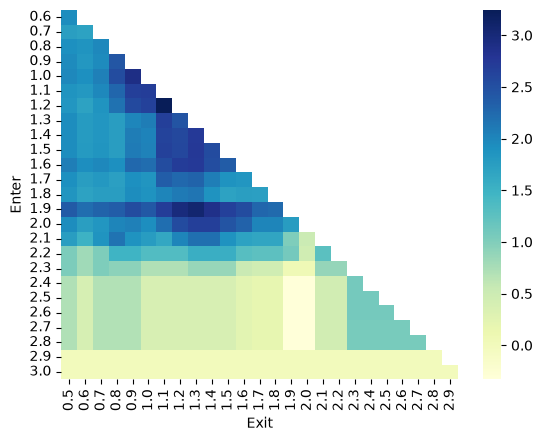

In [86]:
heatmap35 = sns.heatmap(results35_pivot, cmap = "YlGnBu")
plt.show()

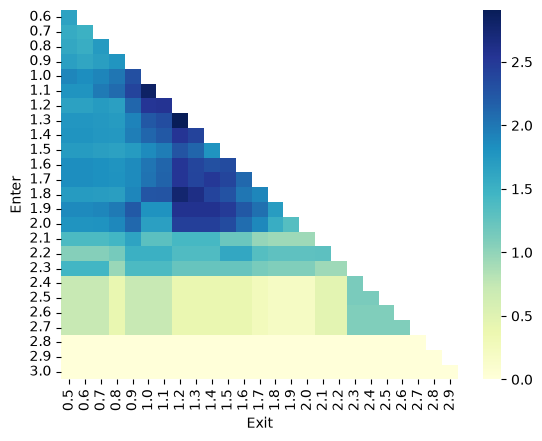

In [92]:
heatmap45 = sns.heatmap(results45_pivot, cmap = "YlGnBu")
plt.show()

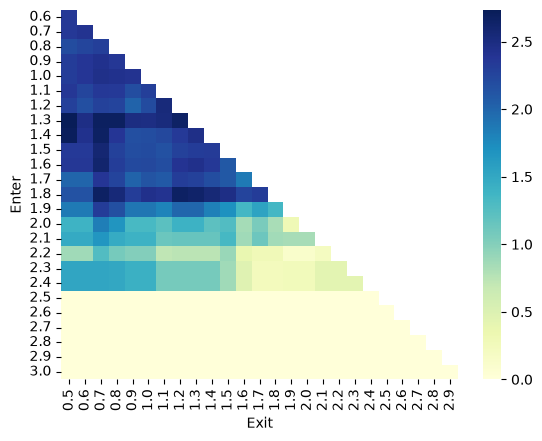

In [93]:
heatmap10 = sns.heatmap(results10_pivot, cmap = "YlGnBu")
plt.show()

In [97]:
print(results10[results10["Sharpe"]>2.6])

     Window  Enter  Exit    Sharpe
353    10.0    1.3   0.5  2.735255
355    10.0    1.3   0.7  2.682541
356    10.0    1.3   0.8  2.685681
360    10.0    1.3   1.2  2.652171
361    10.0    1.4   0.5  2.710121
363    10.0    1.4   0.7  2.661804
382    10.0    1.6   0.7  2.612083
405    10.0    1.8   0.7  2.665352
410    10.0    1.8   1.2  2.665316
411    10.0    1.8   1.3  2.633680


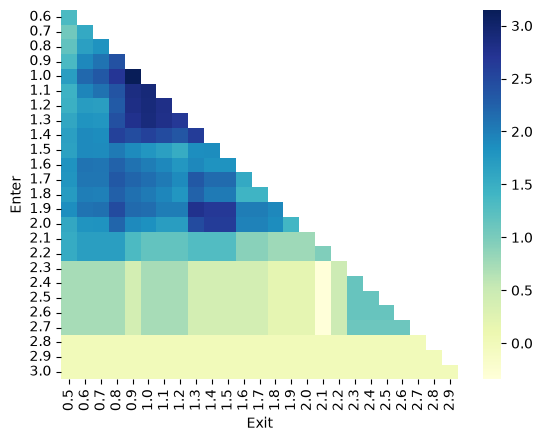

In [94]:
heatmap50 = sns.heatmap(results50_pivot, cmap = "YlGnBu")
plt.show()

After analyzing the heatmaps, I determined that the results for 35 and 45 seem the most coherent with obvious plateaus across broad regions. The inspection of the best results show that the plateaus exhibit similar properties such as a few of nearby parameter sets all have high results, therefore I will choose the set with decent results around it and the highest sharpe in general for the test set.

In [133]:
# 35, 1.9, 1.4, sharpe = 2.27
# 45 1.8, 1.3, sharpe = 0.3
# 10, 1.3, 0.7, 0.85
# 10, 1.4, 0.7, 0.4
window = 35
enter = 2.4
exit = 1.7

In [ ]:
last_day = gld_close.index[-1]
test_z_scores = rolling_z_scores(gld_close, gdx_close, hedge_ratio, split_point, last_day, window)
p_and_l = strategy_p_and_l(gld_open, gdx_open, hedge_ratio, test_z_scores, enter, exit)
percentage_return = np.array(p_and_l.values/(gld_open.shift(1).loc[p_and_l.index]+hedge_ratio*gdx_open.shift(1).loc[p_and_l.index]))
sharpe = np.sqrt(252)*percentage_return.mean()/(percentage_return.std()+eps)
print(len(percentage_return), len(test_z_scores))
percentage_return = pd.Series(data=percentage_return, index = test_z_scores.index)
print(sharpe)

133 133
2.796192259404687


: 

MODIFY THE CODE TO USE DATES BEFORE SPLIT POINT FOR Z_SCORES